<a href="https://colab.research.google.com/github/ChrystinaChin/Computer-Vision/blob/main/Neural_Style_Transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
# Install PyTorch dependencies (usually already installed in Colab)
!pip install pillow torchvision torch


In [ ]:
from google.colab import files

print("Upload your content image first, then style image.")
uploaded = files.upload()


Upload your content image first, then style image.


Saving test.jpg to test (2).jpg
Saving vangogh.webp to vangogh.webp


In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_image(path, max_size=512):
    image = Image.open(path).convert("RGB")

    # Resize for faster processing
    size = min(max(image.size), max_size)

    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0)

# Change these names to match your uploaded files
content_image_path = list(uploaded.keys())[0]
style_image_path = list(uploaded.keys())[1]

content = load_image(content_image_path).to(device)
style = load_image(style_image_path).to(device)


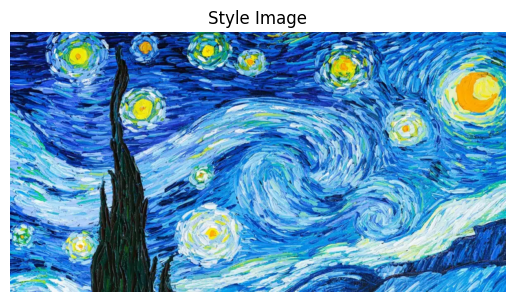

In [ ]:
import matplotlib.pyplot as plt

def show(img_tensor, title=None):
    image = img_tensor.clone().detach().cpu().squeeze()
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    image = image + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    image = image.clamp(0,1)
    plt.imshow(image.permute(1,2,0))
    plt.axis('off')
    if title:
        plt.title(title)

show(content, "Content Image")
show(style, "Style Image")


In [ ]:
from torchvision.models import vgg19, VGG19_Weights

model = vgg19(weights=VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 75.5MB/s]


In [ ]:
layers = {
    '0': 'conv1_1',
    '5': 'conv2_1',
    '10': 'conv3_1',
    '19': 'conv4_1',
    '21': 'content',
    '28': 'conv5_1'
}

def get_features(image, model):
    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x

    return features

def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    return torch.mm(tensor, tensor.t())


In [ ]:
import torch.optim as optim

target = content.clone().requires_grad_(True)

optimizer = optim.Adam([target], lr=0.005)
content_weight = 1
style_weight = 1e6

content_features = get_features(content, model)
style_features = get_features(style, model)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

for step in range(1500):
    target_features = get_features(target, model)

    # Content loss
    content_loss = torch.mean((target_features['content'] - content_features['content'])**2)

    # Style loss
    style_loss = 0
    for layer in style_grams:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        layer_style_loss = torch.mean((target_gram - style_grams[layer])**2)
        style_loss += layer_style_loss

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print(f"Step {step} / 1500 — Loss = {total_loss.item():.4f}")


Step 0 / 1500 — Loss = 138189997223182336.0000


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
result = target.clone().detach().cpu()

def tensor_to_image(tensor):
    tensor = tensor.squeeze()
    tensor = tensor * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    tensor = tensor + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    tensor = tensor.clamp(0,1)
    return transforms.ToPILImage()(tensor)

final_image = tensor_to_image(result)
final_image.save("stylized_result.jpg")

show(target, "Final Stylized Output")
print("Image saved as stylized_result.jpg")


In [ ]:
files.download("stylized_result.jpg")
